In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [3]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(42000, 785)

In [6]:
import matplotlib.pyplot as plt 

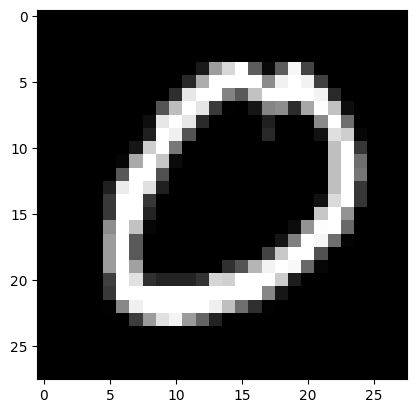

In [7]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28), cmap='gray')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,1:]
y = df.iloc[:,0]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(33600, 784)
(8400, 784)
(33600,)
(8400,)


In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)

KNeighborsClassifier()

In [15]:
import time 
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

10.189942121505737


In [16]:
from sklearn.metrics import accuracy_score

In [17]:
accuracy_score(Y_test,y_pred)

0.9648809523809524

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [20]:
# PCA
from sklearn.decomposition import PCA

In [21]:
pca = PCA(n_components=None)

In [22]:
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [23]:
X_train_trf.shape

(33600, 784)

In [24]:
pca = PCA(n_components=100)

In [25]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [26]:
X_train_trf.shape

(33600, 100)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [28]:
knn.fit(X_train_trf,Y_train)

KNeighborsClassifier()

In [29]:
y_pred = knn.predict(X_test_trf)

In [30]:
accuracy_score(Y_test,y_pred)

0.9692857142857143

In [31]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()

    knn.fit(X_train_trf , Y_train)
    y_pred = knn.predict(X_test_trf)

    print(accuracy_score(Y_test,y_pred))

0.2730952380952381
0.42214285714285715
0.48488095238095236
0.6194047619047619
0.7297619047619047
0.8188095238095238


KeyboardInterrupt: 

In [32]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [33]:
X_train_trf

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]], shape=(33600, 2))

In [34]:
import plotly.express as px

In [35]:
y_train_trf = Y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                y =X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [36]:
# tranforminh in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [37]:
X_train_trf

array([[-226.60523462, -305.89437099, -417.17563833],
       [  38.33583717,  461.09152047, -100.40840682],
       [-305.49225463,  351.67141678,  961.3475787 ],
       ...,
       [ -28.00133402, -596.06287179, -606.25130926],
       [ 233.97011308,  -18.64779077,  148.27481803],
       [1096.50373629,  254.72333173,  560.33354832]], shape=(33600, 3))

In [38]:
y_train_trf = Y_train.astype(str)
fig = px.scatter_3d(df,x=X_train_trf[:,0],y=X_train_trf[:,1],z=X_train_trf[:,2],
                   color=y_train_trf
                   )
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)
fig.show()

In [40]:
pca.explained_variance_
# Eigen values

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [41]:
#Eigen vector

pca.components_.shape

(3, 784)

In [44]:
pca.explained_variance_ratio_

array([0.09770722, 0.07129345, 0.06175413])

In [45]:
pca = PCA(n_components=None)
X_train_trf=pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [46]:
pca.explained_variance_.shape

(784,)

In [48]:
pca.components_.shape

(784, 784)

In [50]:
np.cumsum(pca.explained_variance_ratio_)

array([0.09770722, 0.16900067, 0.2307548 , 0.28465032, 0.33357585,
       0.37694429, 0.40971003, 0.43863706, 0.46634409, 0.4896358 ,
       0.51056687, 0.53103851, 0.54811645, 0.56494851, 0.58079573,
       0.59567555, 0.60890653, 0.6217459 , 0.63357974, 0.6450916 ,
       0.65585129, 0.66609344, 0.6757597 , 0.68493267, 0.69377981,
       0.70211509, 0.7102658 , 0.71801912, 0.72543898, 0.73237223,
       0.73898072, 0.74531281, 0.75134494, 0.75723224, 0.76285054,
       0.76824915, 0.77332825, 0.77819952, 0.78291205, 0.78755761,
       0.79208251, 0.7965231 , 0.80068828, 0.80464464, 0.80848068,
       0.81221196, 0.815819  , 0.81930765, 0.82264965, 0.82582976,
       0.82897181, 0.83204415, 0.83496782, 0.83783336, 0.84062454,
       0.84331783, 0.84596712, 0.84853351, 0.85106204, 0.85351457,
       0.85592008, 0.85831105, 0.86057999, 0.86279635, 0.8649424 ,
       0.86700054, 0.86901774, 0.87098082, 0.87291702, 0.87479944,
       0.87665559, 0.87847316, 0.88022525, 0.88195105, 0.88360

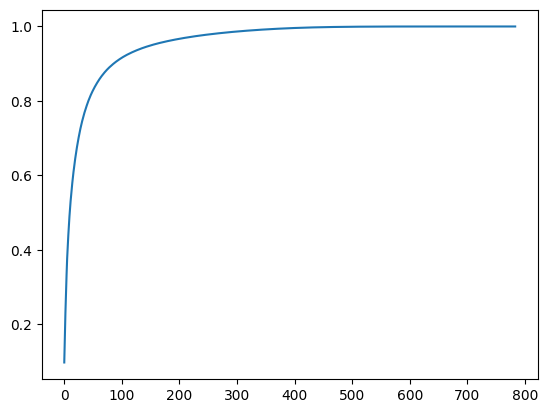

In [51]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))